# 📋 Ejercicio en Clase — Métricas de Evaluación para Regresión
## Diplomado ML en Seguros · Subtema 2

---

### Contexto del ejercicio

Eres actuario en **MedProtect Seguros**, una aseguradora de Gastos Médicos Mayores (GMM) con operaciones en México. El área de Pricing te ha pedido desarrollar y evaluar modelos para predecir:

1. **Regresión:** el monto total de siniestros pagados por póliza en el año (en miles de pesos)
2. **Clasificación:** si una póliza generará siniestralidad alta (por encima de la prima técnica)

Para la primera tarea usarás **Regresión Lineal, Polinómica y Ridge**. Para la segunda, **Regresión Logística**.

### Variables disponibles en el expediente del asegurado

| Variable | Tipo | Descripción |
|----------|------|-------------|
| `edad` | Numérica | Edad del asegurado principal (18–70 años) |
| `genero` | Binaria | 0 = Masculino, 1 = Femenino |
| `bmi` | Numérica | Índice de masa corporal |
| `num_dependientes` | Entera | Número de dependientes cubiertos (0–4) |
| `region` | Categórica | CDMX=0, Norte=1, Centro=2, Sur=3 |
| `fumador` | Binaria | 0 = No fumador, 1 = Fumador |
| `preexistente` | Binaria | 0 = Sin preexistencias, 1 = Con preexistencias |
| `nivel_deducible` | Entera | Nivel de deducible elegido (1=bajo … 4=alto) |
| `suma_asegurada_m` | Numérica | Suma asegurada en millones de pesos (2–20 M) |
| `anios_antiguedad` | Entera | Años como cliente de MedProtect (0–15) |
| `siniestros_previos` | Entera | Número de siniestros en los 3 años anteriores (0–5) |
| `prima_tecnica_k` | Numérica | Prima técnica calculada por el departamento actuarial (MXN miles) |
| **`costo_siniestros_k`** | **Numérica** | **Variable objetivo — regresión** (MXN miles) |
| **`siniestralidad_alta`** | **Binaria** | **Variable objetivo — clasificación**: 1 si costo > prima_tecnica |

---

### Instrucciones generales

- Trabaja en orden: cada sección depende de las anteriores
- Lee con atención las preguntas de reflexión — habrá discusión grupal al final
- **No cambies la semilla aleatoria (random_state=2024)** para que todos obtengan los mismos resultados
- En las secciones marcadas con 🔧 debes escribir código; en las marcadas con 📝 debes responder preguntas

---

**Tiempo estimado:** 90 minutos

---
## Parte 0 — Importar librerías

Ejecuta esta celda sin modificarla.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

from sklearn.linear_model import LinearRegression, Ridge, Lasso, LogisticRegression
from sklearn.preprocessing import PolynomialFeatures, StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.metrics import (
    mean_absolute_error, mean_squared_error, r2_score,
    mean_absolute_percentage_error,
    accuracy_score, confusion_matrix, classification_report,
    roc_auc_score, roc_curve
)

np.random.seed(2024)
plt.rcParams.update({'figure.figsize': (12, 4), 'font.size': 11})
print("✅ Librerías listas.")

✅ Librerías listas.


---
## Parte 1 — Cargar y explorar la base de datos

Ejecuta la siguiente celda para generar el portafolio de MedProtect. **No modifiques nada aquí.**

In [2]:
# ─── Generación del portafolio GMM — MedProtect Seguros ─────────────────────
# 2,500 pólizas individuales de Gastos Médicos Mayores
# NO MODIFICAR — semilla fija para que todos obtengan los mismos resultados

np.random.seed(2024)
N = 2500

# ── Características del asegurado ────────────────────────────────────────────
edad            = np.random.randint(18, 71, N)
genero          = np.random.binomial(1, 0.54, N)          # 54% femenino
bmi             = np.clip(np.random.normal(27.5, 5.0, N), 16, 45).round(1)
num_dependientes= np.random.choice([0,1,2,3,4], N, p=[0.32,0.26,0.24,0.12,0.06])
region          = np.random.choice([0,1,2,3], N, p=[0.38,0.26,0.22,0.14])
fumador         = np.random.binomial(1, 0.16, N)
preexistente    = np.random.binomial(1, 0.28, N)
nivel_deducible = np.random.choice([1,2,3,4], N, p=[0.20,0.35,0.30,0.15])
suma_asegurada  = np.random.choice([2,3,5,10,15,20], N,
                                    p=[0.10,0.15,0.30,0.28,0.12,0.05])
anios_antiguedad= np.random.randint(0, 16, N)
siniestros_prev = np.random.choice([0,1,2,3,4,5], N,
                                    p=[0.52,0.26,0.13,0.05,0.03,0.01])

# ── Prima técnica: fórmula actuarial base ────────────────────────────────────
prima_tecnica = (
    8.0
    + 0.22  * edad
    + 1.8   * genero
    + 0.38  * bmi
    + 2.5   * num_dependientes
    + 4.5   * fumador
    + 12.0  * preexistente
    - 1.5   * nivel_deducible
    + 1.2   * suma_asegurada
    - 0.4   * anios_antiguedad
    + 5.0   * siniestros_prev
    + np.where(region == 0, 3.5, np.where(region == 1, 2.0, np.where(region == 2, 1.0, 0.0)))
    + np.random.normal(0, 4.0, N)
)
prima_tecnica = np.clip(prima_tecnica, 12.0, None).round(2)

# ── Costo de siniestros: relación NO LINEAL con las características ───────────
# La relación real incluye interacciones y efectos curvos
# que la regresión lineal no podrá capturar perfectamente
factor_edad    = 1 + ((edad - 18) / 52) ** 1.6        # curva: sube con la edad
factor_bmi     = np.where(bmi > 30, 1 + (bmi - 30) * 0.05, 1.0)   # solo importa sobre 30
factor_fum     = np.where(fumador == 1, 2.8, 1.0)     # fumadores sinistran 2.8x más
factor_prex    = np.where(preexistente == 1, 3.2, 1.0) # preexistencias: 3.2x más
factor_sin     = 1 + 0.9 * siniestros_prev             # historial pesa fuerte
factor_ded     = 1 / nivel_deducible                   # mayor deducible = menor costo neto
factor_dep     = 1 + 0.35 * num_dependientes
factor_region  = np.where(region==0, 1.15, np.where(region==1, 1.08,
                 np.where(region==2, 1.00, 0.90)))

costo_base = (
    5.0
    * factor_edad
    * factor_fum
    * factor_prex
    * factor_sin
    * factor_bmi
    * factor_ded
    * factor_dep
    * factor_region
)

# Añadir ruido lognormal (los costos médicos tienen cola pesada)
ruido_log = np.random.lognormal(0, 0.8, N)
costo_siniestros = np.clip(costo_base * ruido_log, 0, None).round(2)

# ── Variable de clasificación ──────────────────────────────────────────────
siniestralidad_alta = (costo_siniestros > prima_tecnica).astype(int)

# ── Armar DataFrame ────────────────────────────────────────────────────────
df = pd.DataFrame({
    'edad': edad, 'genero': genero, 'bmi': bmi,
    'num_dependientes': num_dependientes, 'region': region,
    'fumador': fumador, 'preexistente': preexistente,
    'nivel_deducible': nivel_deducible,
    'suma_asegurada_m': suma_asegurada,
    'anios_antiguedad': anios_antiguedad,
    'siniestros_previos': siniestros_prev,
    'prima_tecnica_k': prima_tecnica,
    'costo_siniestros_k': costo_siniestros,
    'siniestralidad_alta': siniestralidad_alta
})

print(f"✅ Portafolio MedProtect: {N:,} pólizas, {df.shape[1]} columnas")
print(f"\n   Costo de siniestros (MXN miles):")
print(f"     Mínimo:  ${df.costo_siniestros_k.min():,.1f}K")
print(f"     Media:   ${df.costo_siniestros_k.mean():,.1f}K")
print(f"     Mediana: ${df.costo_siniestros_k.median():,.1f}K")
print(f"     Máximo:  ${df.costo_siniestros_k.max():,.1f}K")
print(f"\n   Pólizas con siniestralidad ALTA: {siniestralidad_alta.sum():,} "
      f"({siniestralidad_alta.mean()*100:.1f}%)")
print("\nPrimeras 5 pólizas:")
df.head()

✅ Portafolio MedProtect: 2,500 pólizas, 14 columnas

   Costo de siniestros (MXN miles):
     Mínimo:  $0.3K
     Media:   $29.3K
     Mediana: $11.7K
     Máximo:  $1,183.5K

   Pólizas con siniestralidad ALTA: 362 (14.5%)

Primeras 5 pólizas:


,edad,genero,bmi,num_dependientes,region,fumador,preexistente,nivel_deducible,suma_asegurada_m,anios_antiguedad,siniestros_previos,prima_tecnica_k,costo_siniestros_k,siniestralidad_alta
0,26,0,25.1,0,1,1,1,2,5,5,1,51.25,47.21,0
1,50,1,21.6,2,2,0,0,3,10,10,0,43.15,4.21,0
2,18,1,25.8,0,2,0,1,3,15,7,0,43.16,4.27,0
3,45,0,33.9,0,3,0,1,4,5,2,3,60.40,26.23,0
4,54,1,25.2,3,0,0,0,3,5,14,2,48.24,20.17,0


### 🔧 1.1 Análisis exploratorio básico

Completa el código para responder las preguntas.

In [3]:
# 🔧 COMPLETA: muestra estadísticas descriptivas de TODAS las columnas
# Pista: usa df.describe().round(2)

# TU CÓDIGO AQUÍ
df.describe().round(2)

,edad,genero,bmi,num_dependientes,region,fumador,preexistente,nivel_deducible,suma_asegurada_m,anios_antiguedad,siniestros_previos,prima_tecnica_k,costo_siniestros_k,siniestralidad_alta
count,2500.00,2500.00,2500.00,2500.00,2500.00,2500.00,2500.00,2500.00,2500.00,2500.00,2500.00,2500.00,2500.00,2500.00
mean,44.32,0.54,27.51,1.31,1.14,0.16,0.29,2.44,7.51,7.45,0.86,45.35,29.26,0.14
std,15.19,0.50,4.96,1.20,1.09,0.37,0.45,0.97,4.90,4.60,1.13,12.06,59.01,0.35
min,18.00,0.00,16.00,0.00,0.00,0.00,0.00,1.00,2.00,0.00,0.00,15.80,0.33,0.00
25%,31.00,0.00,24.10,0.00,0.00,0.00,0.00,2.00,3.00,3.00,0.00,36.82,5.02,0.00
50%,45.00,1.00,27.40,1.00,1.00,0.00,0.00,2.00,5.00,7.00,0.00,44.26,11.66,0.00
75%,57.00,1.00,30.80,2.00,2.00,0.00,1.00,3.00,10.00,11.00,1.00,52.91,28.76,0.00
max,70.00,1.00,43.80,4.00,3.00,1.00,1.00,4.00,20.00,15.00,5.00,90.08,1183.48,1.00


Media de siniestralidad por grupo:
  - No Fumador: 23.05801909307876
  - Fumador: 61.3179012345679


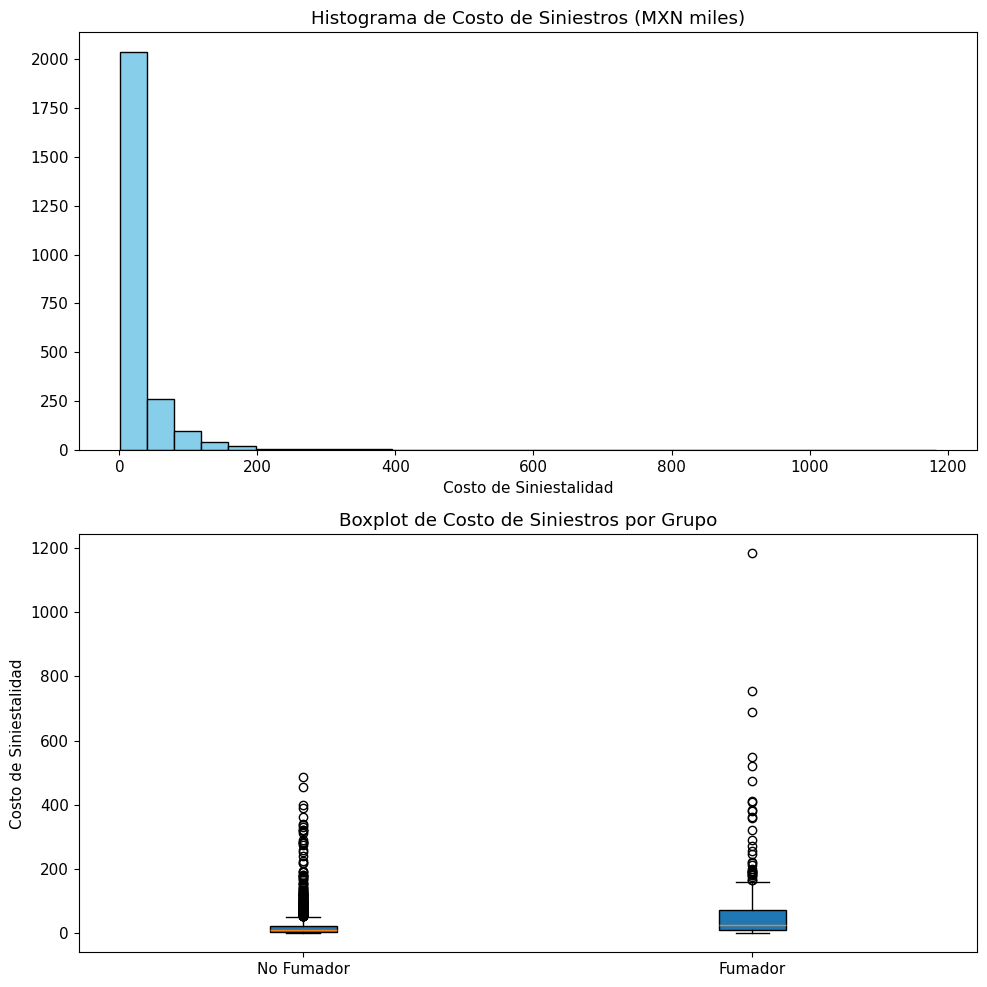

In [ ]:
# 🔧 COMPLETA: genera un histograma de costo_siniestros_k
# Pista: plt.hist(), agrega título y etiqueta del eje x

fig, axes = plt.subplots(2, 1, figsize=(10, 10))

# Panel izquierdo: histograma del costo de siniestros
# TU CÓDIGO AQUÍ

axes[0].hist(df['costo_siniestros_k'], bins=30, color='skyblue', edgecolor='black')
axes[0].set_title('Histograma de Costo de Siniestros')
axes[0].set_xlabel('Costo de Siniestalidad')

# Panel derecho: boxplot de costo_siniestros_k por grupo fumador/no fumador
# Pista: usa df.boxplot() o separa los grupos manualmente
# TU CÓDIGO AQUÍ
axes[1].boxplot([df[df['fumador'] == 0]['costo_siniestros_k'], df[df['fumador'] == 1]['costo_siniestros_k']],
            labels=['No Fumador', 'Fumador'], patch_artist=True)

axes[1].set_title('Boxplot de Costo de Siniestros por Grupo')
axes[1].set_ylabel('Costo de Siniestalidad')

print(f"Media de siniestralidad por grupo:")
print(f"  - No Fumador: {df[df['fumador'] == 0]['costo_siniestros_k'].mean()}")
print(f"  - Fumador: {df[df['fumador'] == 1]['costo_siniestros_k'].mean()}")
plt.tight_layout()
plt.show()

### 📝 Preguntas 1.1

**a)** ¿La distribución del costo de siniestros es simétrica o tiene cola larga? ¿Qué implica esto para las métricas MAE vs RMSE?

*Tu respuesta aquí:*

#### Los costos de los siniestros presentan una distribución de cola larga, esto tiene que tomarse en cuenta al momento de análizar las métricas como RMSE que se ven afectadas por valores extremos y a la razón entre el MAE/RMSE, ya que, su valor se puede alzar mucho por lo mismo.
---

**b)** ¿Cuánto más alto es el costo promedio en fumadores vs no fumadores? ¿Era esperado ese resultado?

*Tu respuesta aquí:*

#### El costro promedio en fumadores es casi 3 veces mayor a los no fumadores, esto es lógico, ya que este hábito es uno de los más dañinos para la salud
---

---
## Parte 2 — Partición y preparación de datos

### 🔧 2.1 Separar train y test

In [14]:
# Variables predictoras para regresión
FEATURES = ['edad', 'genero', 'bmi', 'num_dependientes', 'region',
            'fumador', 'preexistente', 'nivel_deducible',
            'suma_asegurada_m', 'anios_antiguedad', 'siniestros_previos']

X = df[FEATURES].values
y = df['costo_siniestros_k'].values
y_clas = df['siniestralidad_alta'].values

# 🔧 COMPLETA: separa X e y en train (80%) y test (20%)
# Usa random_state=2024 para reproducibilidad
# Pista: train_test_split(X, y, test_size=..., random_state=...)

# TU CÓDIGO AQUÍ
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=2024)

print(f"Train: {len(X_train):,} pólizas | Test: {len(X_test):,} pólizas")
print(f"Media de costo en train: ${y_train.mean():,.1f}K")
print(f"Media de costo en test:  ${y_test.mean():,.1f}K")
print("¿Las medias son similares? Deben serlo si la separación fue aleatoria.")

Train: 2,000 pólizas | Test: 500 pólizas
Media de costo en train: $29.8K
Media de costo en test:  $27.1K
¿Las medias son similares? Deben serlo si la separación fue aleatoria.


In [15]:
# 🔧 COMPLETA: crea el StandardScaler, ajústalo SOLO en train
# y transforma tanto train como test
# IMPORTANTE: scaler.fit() SOLO sobre X_train — nunca sobre X_test

scaler = StandardScaler()

# TU CÓDIGO AQUÍ
X_train_sc = scaler.fit_transform(X_train)
X_test_sc  = scaler.transform(X_test)

print("Medias aprendidas del train (deben ser ~0 después de escalar):")
print(f"  Media de X_train_sc columna 'edad': {X_train_sc[:, 0].mean():.4f}")
print(f"  Std de X_train_sc columna 'edad':   {X_train_sc[:, 0].std():.4f}")

Medias aprendidas del train (deben ser ~0 después de escalar):
  Media de X_train_sc columna 'edad': 0.0000
  Std de X_train_sc columna 'edad':   1.0000


---
## Parte 3 — Regresión Lineal y cálculo de métricas

### 🔧 3.1 Entrenar el modelo

In [16]:
# 🔧 COMPLETA: entrena una Regresión Lineal con X_train_sc y y_train
# Luego predice sobre X_train_sc y X_test_sc

lr = LinearRegression()

# TU CÓDIGO AQUÍ
lr.fit(X_train_sc, y_train)
y_pred_train_lr = lr.predict(X_train_sc)
y_pred_test_lr  = lr.predict(X_test_sc)

print("Regresión Lineal entrenada.")
print(f"\nCoeficientes más grandes (los 3 predictores más influyentes):")
coef_df = pd.Series(lr.coef_, index=FEATURES).abs().sort_values(ascending=False)
print(coef_df.head(3))

Regresión Lineal entrenada.

Coeficientes más grandes (los 3 predictores más influyentes):
preexistente          17.451108
siniestros_previos    17.405473
fumador               15.479550
dtype: float64


### 🔧 3.2 Calcular MAE, MSE, RMSE, R² y MAPE paso a paso

Calcula primero manualmente (con numpy) y luego verifica con sklearn.

In [27]:
# ─── CÁLCULO MANUAL — para entender cada fórmula ────────────────────────────

errores = y_test - y_pred_test_lr   # vector de errores (y - ŷ)

# 🔧 COMPLETA: calcula cada métrica usando numpy sin sklearn

# MAE = (1/n) * Σ|errores|
mae_manual = np.abs(errores).sum()/ len(y_test)   # TU CÓDIGO AQUÍ

# MSE = (1/n) * Σ(errores²)
mse_manual = (errores**2).sum()/ len(y_test)  # TU CÓDIGO AQUÍ

# RMSE = sqrt(MSE)
rmse_manual = np.sqrt(mse_manual)  # TU CÓDIGO AQUÍ

# R² = 1 - SS_res / SS_tot
ss_res = np.sum(errores**2)
ss_tot = np.sum((y_test - y_test.mean())**2)
r2_manual =1 - ss_res/ss_tot    # TU CÓDIGO AQUÍ

# MAPE = (100/n) * Σ|errores| / |y_test|
# ATENCIÓN: excluye pólizas con costo=0 para evitar división por cero
mask_nonzero = y_test > 0
mape_manual =  (errores/y_test).sum()*(100/len(y_test)) # TU CÓDIGO AQUÍ

print("=" * 55)
print("  MÉTRICAS — CÁLCULO MANUAL (Regresión Lineal)")
print("=" * 55)
print(f"  MAE:  ${mae_manual:>10,.2f} K")
print(f"  MSE:  {mse_manual:>12,.0f} K²")
print(f"  RMSE: ${rmse_manual:>10,.2f} K")
print(f"  R²:   {r2_manual:>12.4f}")
print(f"  MAPE: {mape_manual:>11.1f} %")
print(f"  Razón RMSE/MAE: {rmse_manual/mae_manual:.2f}")

  MÉTRICAS — CÁLCULO MANUAL (Regresión Lineal)
  MAE:  $     24.98 K
  MSE:         1,655 K²
  RMSE: $     40.68 K
  R²:         0.2962
  MAPE:         3.7 %
  Razón RMSE/MAE: 1.63


In [28]:
# ─── VERIFICACIÓN CON SKLEARN ────────────────────────────────────────────────
# Los números deben coincidir exactamente con los calculados manualmente

# 🔧 COMPLETA: calcula las mismas métricas usando sklearn.metrics
# Pista: mean_absolute_error, mean_squared_error, r2_score,
#        mean_absolute_percentage_error (multiplica por 100 para el %)

mae_sk  = mean_absolute_error(y_test, y_pred_test_lr)    # TU CÓDIGO AQUÍ
mse_sk  = mean_squared_error(y_test, y_pred_test_lr)    # TU CÓDIGO AQUÍ
rmse_sk = np.sqrt(mse_sk)                               # TU CÓDIGO AQUÍ
r2_sk   = r2_score(y_test, y_pred_test_lr)              # TU CÓDIGO AQUÍ
mape_sk = mean_absolute_percentage_error(y_test, y_pred_test_lr) * 100  # TU CÓDIGO AQUÍ

print("=" * 55)
print("  VERIFICACIÓN CON SKLEARN")
print("=" * 55)
print(f"  MAE  sklearn: ${mae_sk:>10,.2f} K  — ¿igual al manual? {abs(mae_sk-mae_manual)<0.01}")
print(f"  MSE  sklearn: {mse_sk:>12,.0f} K²")
print(f"  RMSE sklearn: ${rmse_sk:>10,.2f} K  — ¿igual al manual? {abs(rmse_sk-rmse_manual)<0.01}")
print(f"  R²   sklearn: {r2_sk:>12.4f}  — ¿igual al manual? {abs(r2_sk-r2_manual)<0.0001}")

  VERIFICACIÓN CON SKLEARN
  MAE  sklearn: $     24.98 K  — ¿igual al manual? True
  MSE  sklearn:        1,655 K²
  RMSE sklearn: $     40.68 K  — ¿igual al manual? True
  R²   sklearn:       0.2962  — ¿igual al manual? True


### 📝 Preguntas 3.2

**a)** La razón RMSE/MAE que obtuviste, ¿qué indica sobre la distribución de los errores? Consulta la guía (Sección 2.3) para interpretar el valor.

*Tu respuesta aquí:*

#### Obtuvimos una razon de 1.63 lo cual nos indica que hay errores grandes y se deben investigar las pólizas que las causan.
---

**b)** El R² que obtuviste, ¿es bueno o malo para este tipo de problema? Recuerda que estamos prediciendo costos de GMM con alta variabilidad inherente.

*Tu respuesta aquí:*

#### El R^2 es moderado, no es realmente bueno, pero podemos decir que nuestro modelo es valido
---

### 🔧 3.3 Comparar train vs test — detectar overfitting

In [29]:
# 🔧 COMPLETA: calcula MAE y R² tanto en TRAIN como en TEST para el modelo lineal
# Luego interpreta si hay overfitting o underfitting

mae_train_lr = mean_absolute_error(y_train, y_pred_train_lr)
mae_test_lr  = mean_absolute_error(y_test,  y_pred_test_lr)
r2_train_lr  = r2_score(y_train, y_pred_train_lr)  # TU CÓDIGO AQUÍ
r2_test_lr   = r2_score(y_test, y_pred_test_lr)   # TU CÓDIGO AQUÍ

print(f"  Regresión Lineal:")
print(f"    MAE  train: ${mae_train_lr:,.2f} K    MAE test: ${mae_test_lr:,.2f} K")
print(f"    R²  train:  {r2_train_lr:.4f}       R² test:  {r2_test_lr:.4f}")
print(f"    Diferencia R² (train-test): {r2_train_lr - r2_test_lr:.4f}")
print()

# 🔧 COMPLETA: escribe aquí el diagnóstico
# ¿El modelo tiene underfitting, buen balance, o overfitting?
# Regla: si R²_train - R²_test > 0.15 → overfitting
#        si R²_train < 0.30            → underfitting probable

diferencia_r2 = r2_train_lr - r2_test_lr
if diferencia_r2 > 0.15:
    print("  Diagnóstico: OVERFITTING")
elif r2_train_lr < 0.30:
    print("  Diagnóstico: posible UNDERFITTING — modelo muy simple")
else:
    print("  Diagnóstico: BALANCE ACEPTABLE sesgo-varianza")

  Regresión Lineal:
    MAE  train: $25.29 K    MAE test: $24.98 K
    R²  train:  0.3210       R² test:  0.2962
    Diferencia R² (train-test): 0.0248

  Diagnóstico: BALANCE ACEPTABLE sesgo-varianza


---
## Parte 4 — Regresión Polinómica

La relación entre la edad y el costo médico no es lineal: la siniestralidad sube más rápido en personas mayores. La Regresión Polinómica puede capturar esto.

### 🔧 4.1 Comparar grados 1, 2 y 3

In [31]:
# 🔧 COMPLETA: entrena tres pipelines polinómicos (grado 1, 2, 3)
# Usa Pipeline([('poly', PolynomialFeatures(degree=...)),
#               ('sc',   StandardScaler()),
#               ('lr',   LinearRegression())])
# Evalúa MAE y R² en train y test para cada grado

print(f"{'Grado':>6}  {'MAE Train':>11}  {'MAE Test':>10}  {'R² Train':>9}  {'R² Test':>8}  {'Diagnóstico'}")
print("-" * 78)

resultados_poly = {}

for grado in [1, 2, 3]:
    # TU CÓDIGO AQUÍ — construye el pipeline y ajústalo
    pipe = Pipeline([
        ('poly', PolynomialFeatures(degree=grado, include_bias=False)),
        ('sc',   StandardScaler()),
        ('lr',   LinearRegression())
    ])
    pipe.fit(X_train, y_train)   # fit con X_train sin escalar (el pipeline lo hace)

    # TU CÓDIGO AQUÍ — predice y calcula métricas
    pred_train = pipe.predict(X_train)
    pred_test  = pipe.predict(X_test)

    mae_tr = mean_absolute_error(y_train, pred_train)
    mae_te = mean_absolute_error(y_test, pred_test)
    r2_tr  = r2_score(y_train, pred_train)
    r2_te  = r2_score(y_test, pred_test)

    resultados_poly[grado] = {'pipe': pipe, 'mae_tr': mae_tr, 'mae_te': mae_te,
                              'r2_tr': r2_tr, 'r2_te': r2_te}

    # Diagnóstico automático
    diff = r2_tr - r2_te
    if diff > 0.15:
        diag = "🔴 OVERFITTING"
    elif r2_tr < 0.25:
        diag = "⚠️  UNDERFITTING"
    else:
        diag = "✅ BALANCE OK"

    print(f"  {grado:>4}  ${mae_tr:>9,.1f} K  ${mae_te:>8,.1f} K  "
          f"{r2_tr:>9.4f}  {r2_te:>8.4f}  {diag}")

 Grado    MAE Train    MAE Test   R² Train   R² Test  Diagnóstico
------------------------------------------------------------------------------
     1  $     25.3 K  $    25.0 K     0.3210    0.2962  ✅ BALANCE OK
     2  $     20.9 K  $    21.6 K     0.5054    0.3258  🔴 OVERFITTING
     3  $     19.8 K  $    26.1 K     0.6474    0.0563  🔴 OVERFITTING


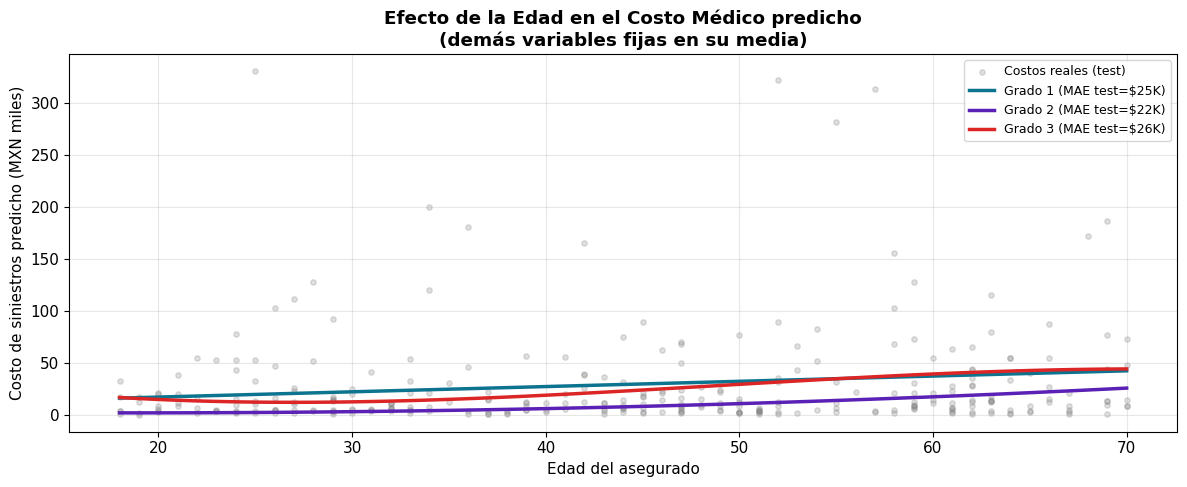

In [32]:
# 🔧 COMPLETA: visualiza el efecto de la edad en el costo predicho
# para los tres grados, manteniendo fijas las demás variables en su media

# Crear una grilla de edades (18 a 70)
edades_grilla = np.linspace(18, 70, 100)

# Fijamos todas las demás variables en la media del train
X_train_df = pd.DataFrame(X_train, columns=FEATURES)
medias = X_train_df.mean()

fig, ax = plt.subplots(figsize=(12, 5))

# Puntos reales del test (muestra de 300)
idx_muestra = np.random.choice(len(X_test), 300, replace=False)
ax.scatter(X_test[idx_muestra, 0], y_test[idx_muestra],
           alpha=0.25, s=15, color='gray', label='Costos reales (test)')

colores = ['#0D7490', '#5B21B6', '#DC2626']

for grado, color in zip([1, 2, 3], colores):
    # Construir el X de la grilla: edad varía, resto = medias
    X_grilla = np.tile(medias.values, (100, 1))
    X_grilla[:, 0] = edades_grilla   # columna 0 = edad

    pipe = resultados_poly[grado]['pipe']
    pred_grilla = pipe.predict(X_grilla)

    ax.plot(edades_grilla, pred_grilla, linewidth=2.5, color=color,
            label=f'Grado {grado} (MAE test=${resultados_poly[grado]["mae_te"]:,.0f}K)')

ax.set_xlabel('Edad del asegurado')
ax.set_ylabel('Costo de siniestros predicho (MXN miles)')
ax.set_title('Efecto de la Edad en el Costo Médico predicho\n'
             '(demás variables fijas en su media)', fontweight='bold')
ax.legend(fontsize=9)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('poly_vs_edad.png', dpi=150, bbox_inches='tight')
plt.show()

### 📝 Preguntas 4.1

**a)** Al aumentar el grado del polinomio, ¿el MAE en train sube o baja? ¿Y el MAE en test? Explica por qué.

*Tu respuesta aquí:*
#### En entrenamiento va disminuyendo, pero en el test aumenta del grado 1 a 3, esto se debe a que, al aumentar la complejidad del modelo parece que en el entrenamiento se va ajustando mejor conforme el grado aumenta, pero se observa un sobre ajuste, ya que, el comportamiento en el test no se comporta igual a los datos con los que entrenamos.
---

**b)** ¿Cuál grado recomendarías para producción? Justifica con las métricas de la tabla y con el gráfico.

*Tu respuesta aquí:*

#### Escogeriamos el de grado 1 (regresión lineal), en primer lugar por que es el más sencillo y los demás modelos no compensan sus resultados con la complejidad del mismo, además que el de grado 1 tiene un mejor balance en las R^2 de entrenamiento y prueba.

---

**c)** La curva de grado 2 o 3, ¿captura mejor que la recta el hecho de que la siniestralidad sube más rápido en edades avanzadas? ¿Qué le dirías al área de Pricing sobre este hallazgo?

*Tu respuesta aquí:*
#### La de grado 1 y 3 son las curvas que mejor perciben el crecimiento de la siniestralidad en edades avanzadas, sin embargo, en el rango de (20-40) la linea recta sobreestima el riesgo en comparación a lo que detecta las otras dos curvas.
---

---
## Parte 5 — Ridge: regularización para controlar overfitting

### 🔧 5.1 Encontrar el mejor λ con Cross-Validation

In [ ]:
# 🔧 COMPLETA: evalúa Ridge con distintos valores de α (lambda)
# Usa cross_val_score con K=5 sobre X_train_sc y y_train
# scoring='neg_mean_absolute_error'

alphas = [0.01, 0.1, 1, 10, 50, 100, 500, 1000]
resultados_ridge = []

print(f"{'Alpha (λ)':>12}  {'CV-5 MAE':>15}  {'Std MAE':>12}")
print("-" * 45)

for alpha in alphas:
    ridge = Ridge(alpha=alpha)

    # TU CÓDIGO AQUÍ — usa cross_val_score
    scores = cross_val_score(
        ridge, X_train_sc, y_train,
        cv=5, scoring='neg_mean_absolute_error'
    )
    mae_cv = 
    std_cv = ...

    resultados_ridge.append({'alpha': alpha, 'mae': mae_cv, 'std': std_cv})
    print(f"  {alpha:>10}  ${mae_cv:>12,.2f} K  ±${std_cv:>9,.2f} K")

df_ridge = pd.DataFrame(resultados_ridge)
mejor_alpha = df_ridge.loc[df_ridge['mae'].idxmin(), 'alpha']
print(f"\n✅ Mejor α por CV-5: {mejor_alpha}")

In [ ]:
# 🔧 COMPLETA: entrena Ridge con el mejor alpha en TODO X_train_sc
# y evalúa en X_test_sc

ridge_final = Ridge(alpha=mejor_alpha)

# TU CÓDIGO AQUÍ
ridge_final.fit(...)
pred_test_ridge = ...

mae_ridge  = mean_absolute_error(y_test, pred_test_ridge)
rmse_ridge = np.sqrt(mean_squared_error(y_test, pred_test_ridge))
r2_ridge   = r2_score(y_test, pred_test_ridge)

print(f"Ridge (α={mejor_alpha}) — Evaluación en TEST:")
print(f"  MAE:  ${mae_ridge:,.2f} K")
print(f"  RMSE: ${rmse_ridge:,.2f} K")
print(f"  R²:   {r2_ridge:.4f}")
print(f"  RMSE/MAE: {rmse_ridge/mae_ridge:.2f}")

---
## Parte 6 — Tabla comparativa y análisis de residuos

### 🔧 6.1 Tabla resumen de todos los modelos

In [ ]:
# 🔧 COMPLETA: llena la tabla con las métricas de los 5 modelos
# (Lineal, Polinomio grado 2, Polinomio grado 3, Ridge)
# Para cada uno reporta: MAE test, RMSE test, R² test, RMSE/MAE

print(f"{'Modelo':25s}  {'MAE Test':>11}  {'RMSE Test':>10}  {'R² Test':>8}  {'RMSE/MAE':>9}  {'Recomendación'}")
print("-" * 95)

# Recopila los resultados de las secciones anteriores
modelos_comparar = [
    ('Regresión Lineal',     mae_test_lr,
     np.sqrt(mean_squared_error(y_test, y_pred_test_lr)), r2_test_lr),
    # 🔧 AGREGA los demás: Polinomio grado 2, grado 3, Ridge
    # TU CÓDIGO AQUÍ
]

for nombre, mae, rmse, r2 in modelos_comparar:
    ratio = rmse / mae
    if ratio > 2.0:
        rec = "⚠️ Errores muy heterogéneos"
    elif r2 > 0.40:
        rec = "✅ Buen poder predictivo"
    elif r2 > 0.20:
        rec = "Aceptable — alta variabilidad inherente"
    else:
        rec = "🔴 Revisar modelo"
    print(f"{nombre:25s}  ${mae:>9,.1f} K  ${rmse:>8,.1f} K  {r2:>8.4f}  {ratio:>9.2f}  {rec}")

### 🔧 6.2 Análisis de residuos del mejor modelo

In [ ]:
# 🔧 COMPLETA: usa el mejor modelo de la tabla anterior
# Genera 3 gráficas de diagnóstico de residuos

# 1) Identifica cuál fue el mejor modelo por MAE test
# y usa sus predicciones sobre el test set

# TU CÓDIGO AQUÍ: asigna las predicciones del mejor modelo
y_pred_mejor = ...   # predicciones del mejor modelo en test
nombre_mejor = "..." # nombre del modelo

residuos = y_test - y_pred_mejor

fig, axes = plt.subplots(1, 3, figsize=(16, 5))
fig.suptitle(f'Análisis de Residuos — {nombre_mejor}', fontweight='bold')

# Panel 1: Real vs Predicho
ax = axes[0]
# 🔧 COMPLETA: scatter de y_test vs y_pred_mejor + línea de predicción perfecta
# TU CÓDIGO AQUÍ
ax.set_xlabel('Costo real (MXN miles)')
ax.set_ylabel('Costo predicho (MXN miles)')
ax.set_title('Real vs Predicho')

# Panel 2: Residuos vs valores predichos
ax = axes[1]
# 🔧 COMPLETA: scatter de y_pred_mejor vs residuos + línea horizontal en 0
# TU CÓDIGO AQUÍ
ax.set_xlabel('Costo predicho (MXN miles)')
ax.set_ylabel('Residuo (Real − Predicho)')
ax.set_title('Residuos vs Predicho\n(debe ser nube aleatoria sin patrón)')

# Panel 3: Histograma de residuos
ax = axes[2]
# 🔧 COMPLETA: histograma de residuos
# TU CÓDIGO AQUÍ
ax.set_xlabel('Residuo (MXN miles)')
ax.set_title(f'Distribución de Residuos\nMAE=${mean_absolute_error(y_test,y_pred_mejor):,.1f}K')

plt.tight_layout()
plt.savefig('residuos_mejor_modelo.png', dpi=150, bbox_inches='tight')
plt.show()

### 📝 Preguntas 6.2

**a)** En el gráfico de Residuos vs Predicho, ¿observas algún patrón (forma de abanico, curva, etc.)? ¿Qué significa si hay un patrón claro?

*Tu respuesta aquí:*

---

**b)** El histograma de residuos, ¿es simétrico o tiene cola? ¿Hay más errores positivos o negativos? ¿Qué implica esto para el área de Pricing?

*Tu respuesta aquí:*

---

---
## Resumen de lo que practicaste

| Concepto | Dónde lo aplicaste |
|----------|-------------------|
| Separar train/test ANTES de escalar | Sección 2 |
| MAE, MSE, RMSE, R², MAPE — cálculo manual y con sklearn | Sección 3 |
| Razón RMSE/MAE como diagnóstico de errores heterogéneos | Sección 3 |
| Comparar train vs test para detectar overfitting | Sección 3.3 |
| Regresión Polinómica — tradeoff sesgo-varianza | Sección 4 |
| Ridge — regularización con Cross-Validation | Sección 5 |
| Tabla comparativa — elegir el mejor modelo | Sección 6 |
| Análisis de residuos — diagnóstico gráfico | Sección 6.2 |